In [1]:
from pluot import render_to_image

In [2]:
result = await render_to_image(width=300, height=300, plotId="test2", plotType="triangle", storeName="test")

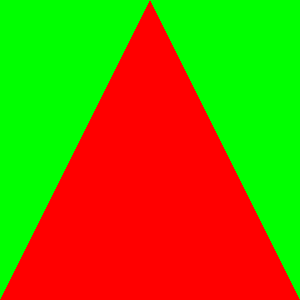

In [3]:
result

In [18]:
camera_view = [
    0.15, 0.0, 0.0, 0.0,
    0.0, 0.15, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

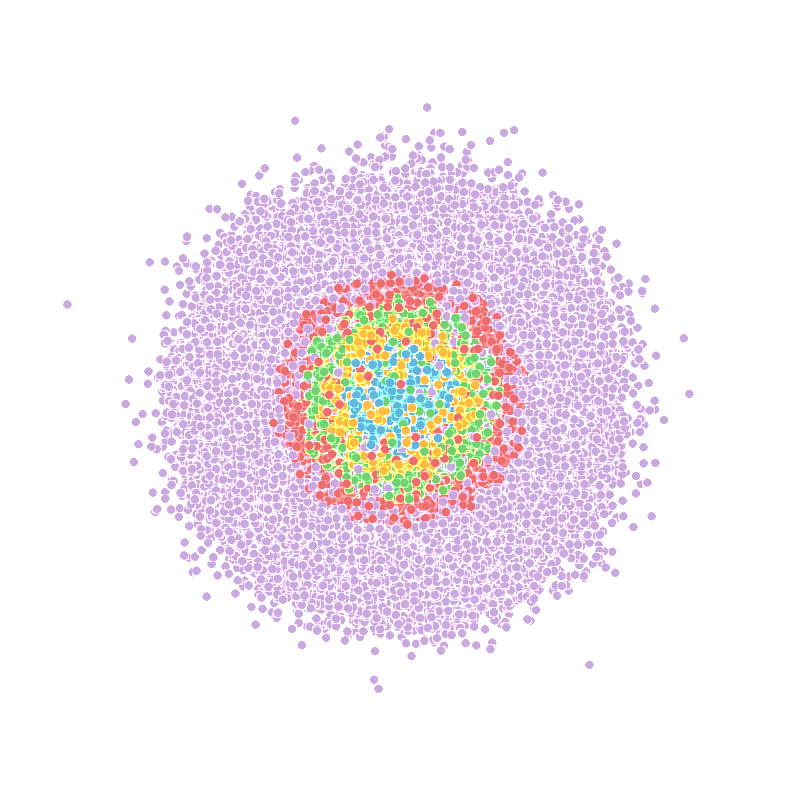

In [23]:
await render_to_image(
    cameraView=camera_view, width=800, height=800, plotId="test", plotType="scatterplot", storeName="my_store",
    x_key="/n_1000000/x_coords", y_key="/n_1000000/y_coords", color_key="/n_1000000/class_labels",
    point_radius=10.0
)

In [25]:
import zarr
import pluot.zarr
from os.path import join

#await pluot.zarr.zarr_get("my_store", "n_1000000/x_coords/zarr.json")

In [26]:
pluot.zarr.GLOBAL_STORES["mnist_store"] = zarr.storage.LocalStore(join("..", "data", "out", "mnist.zarr"))

In [27]:
import numpy as np

In [28]:
x_arr = np.array([-1, -1, 1, 1], dtype=float)
y_arr = np.array([-1, 1, -1, 1], dtype=float)
labels_arr = np.array([1, 2, 3, 4], dtype=int)

In [29]:
z = zarr.open(join("..", "data", "out", "screen_quad.zarr"))

no_compression = dict(filters=None, compressors=None, serializer="auto")

z.create_array(name=f"/x_coords", data=x_arr.astype(float), **no_compression)
z.create_array(name=f"/y_coords", data=y_arr.astype(float), **no_compression)
z.create_array(name=f"/class_labels", data=labels_arr.astype(int), **no_compression)

ContainsArrayError: An array exists in store LocalStore('file://../data/out/screen_quad.zarr') at path 'x_coords'.

In [30]:
pluot.zarr.GLOBAL_STORES["screen_quad"] = zarr.storage.LocalStore(join("..", "data", "out", "screen_quad.zarr"))

In [31]:
#await pluot.zarr.zarr_get("mnist_store", "umap/x_coords/zarr.json")

In [461]:
camera_view = [
    0.125, 0.0, 0.0, 0.0,
    0.0, 0.125, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    0.0, 0.0, 0.0, 1.0,
]

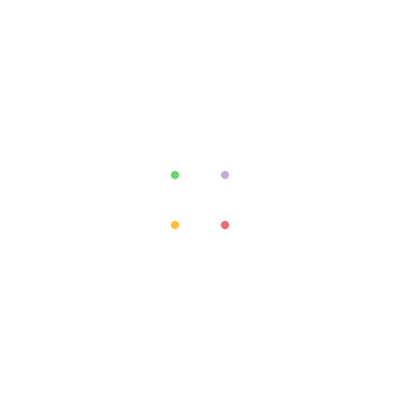

In [462]:
await render_to_image(
    cameraView=camera_view,
    width=400,
    height=400,
    plotId="test",
    plotType="scatterplot",
    storeName="screen_quad",
    x_key="/x_coords",
    y_key="/y_coords",
    color_key="/class_labels",
    point_radius=10.0
)

In [463]:
zoom = camera_view[0]
translate_x = camera_view[12]
translate_y = camera_view[13]
min_x = (-translate_x - 1)/zoom
max_x = (-translate_x + 1)/zoom
min_y = (-translate_y - 1)/zoom
max_y = (-translate_y + 1)/zoom
print(f"{zoom=}, {translate_x=}, {min_x=}, {max_x=}, {min_y=}, {max_y=}, {2.0/zoom}")

zoom=0.125, translate_x=0.0, min_x=-8.0, max_x=8.0, min_y=-8.0, max_y=8.0, 16.0


In [465]:
np.log2(1/.0)

np.float64(-2.0)

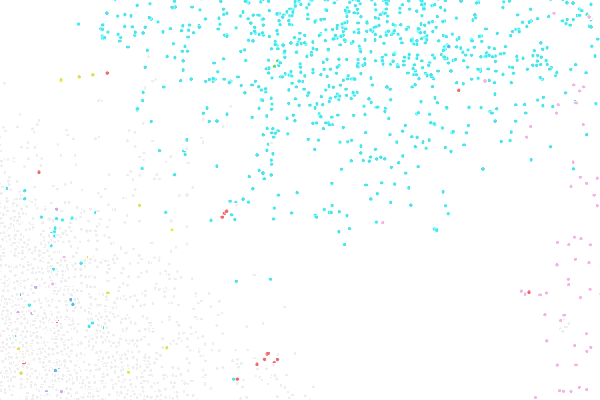

In [320]:
await render_to_image(
    cameraView=camera_view,
    width=600,
    height=400,
    plotId="test",
    plotType="scatterplot",
    storeName="mnist_store",
    x_key="/densmap/x_coords",
    y_key="/densmap/y_coords",
    color_key="/densmap/class_labels",
)